In [1]:
import pandas as pd
print("Pandas loaded successfully! Version:", pd.__version__)

Pandas loaded successfully! Version: 2.3.3


In [2]:
# Load the dataset
df_activity = pd.read_csv('dailyActivity_merged.csv')

# Display the first 5 rows to understand the structure
print("--- FIRST 5 ROWS OF THE DATASET ---")
print(df_activity.head())

--- FIRST 5 ROWS OF THE DATASET ---
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    3/25/2016       11004           7.11             7.11   
1  1503960366    3/26/2016       17609          11.55            11.55   
2  1503960366    3/27/2016       12736           8.53             8.53   
3  1503960366    3/28/2016       13231           8.93             8.93   
4  1503960366    3/29/2016       12041           7.85             7.85   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                2.57                      0.46   
1                       0.0                6.92                      0.73   
2                       0.0                4.66                      0.16   
3                       0.0                3.19                      0.79   
4                       0.0                2.16                      1.09   

   LightActiveDistance  SedentaryActiveDistance  VeryAct

In [3]:
# Check data types and missing values
print(df_activity.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [4]:
# Save the table into a variable called df
df = pd.read_csv('dailyActivity_merged.csv')

# Check data types and structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [5]:
# Convert ActivityDate from object (text) to datetime format
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'], format='%m/%d/%Y')

# Verify the change
print("New data type for ActivityDate:")
print(df['ActivityDate'].dtype)

New data type for ActivityDate:
datetime64[ns]


In [6]:
# Create a new column with the day of the week
df['DayOfWeek'] = df['ActivityDate'].dt.day_name()

# Check the result by displaying the first 5 rows of these columns
print(df[['ActivityDate', 'DayOfWeek']].head())

  ActivityDate DayOfWeek
0   2016-03-25    Friday
1   2016-03-26  Saturday
2   2016-03-27    Sunday
3   2016-03-28    Monday
4   2016-03-29   Tuesday


In [7]:
# Calculate the average number of steps
average_steps = df['TotalSteps'].mean()
print("Average daily steps per user:", round(average_steps, 2))

# Calculate the maximum and minimum steps to see the contrast
max_steps = df['TotalSteps'].max()
min_steps = df['TotalSteps'].min()
print("Maximum steps in a single day:", max_steps)
print("Minimum steps in a single day:", min_steps)

Average daily steps per user: 6546.56
Maximum steps in a single day: 28497
Minimum steps in a single day: 0


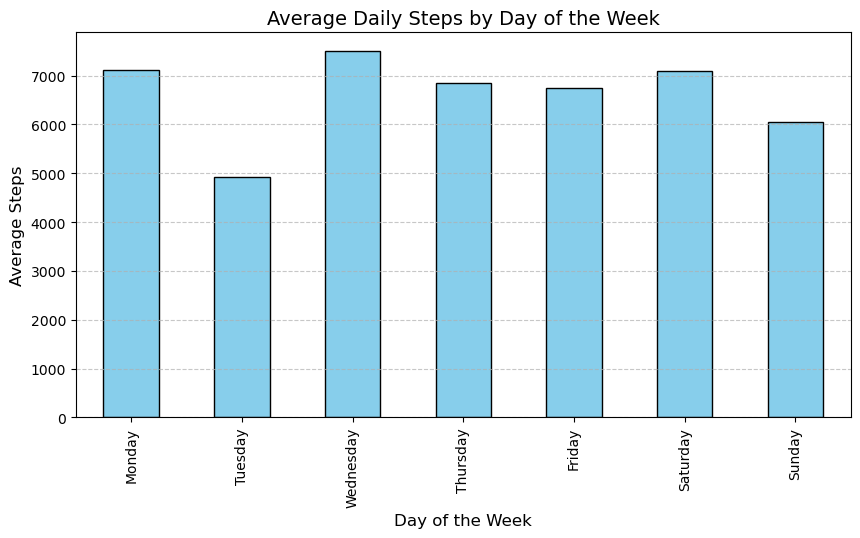

In [9]:
import matplotlib.pyplot as plt

# Group data by DayOfWeek and calculate average steps for each day
weekday_steps = df.groupby('DayOfWeek')['TotalSteps'].mean()

# Order days logically from Monday to Sunday
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_steps = weekday_steps.reindex(days_order)

# Plot the data
plt.figure(figsize=(10, 5))
weekday_steps.plot(kind='bar', color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Average Daily Steps by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Steps', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [10]:
# Calculate the average minutes for each activity intensity
avg_very_active = df['VeryActiveMinutes'].mean()
avg_fairly_active = df['FairlyActiveMinutes'].mean()
avg_lightly_active = df['LightlyActiveMinutes'].mean()
avg_sedentary = df['SedentaryMinutes'].mean()

print("--- Average Minutes Per Day Per User ---")
print("Very Active Minutes:", round(avg_very_active, 1))
print("Fairly Active Minutes:", round(avg_fairly_active, 1))
print("Lightly Active Minutes:", round(avg_lightly_active, 1))
print("Sedentary Minutes (Inactivity):", round(avg_sedentary, 1))

--- Average Minutes Per Day Per User ---
Very Active Minutes: 16.6
Fairly Active Minutes: 13.1
Lightly Active Minutes: 170.1
Sedentary Minutes (Inactivity): 995.3


In [11]:
# Convert sedentary minutes to hours
sedentary_hours = avg_sedentary / 60
print("Average sedentary time per day:", round(sedentary_hours, 1), "hours")

Average sedentary time per day: 16.6 hours


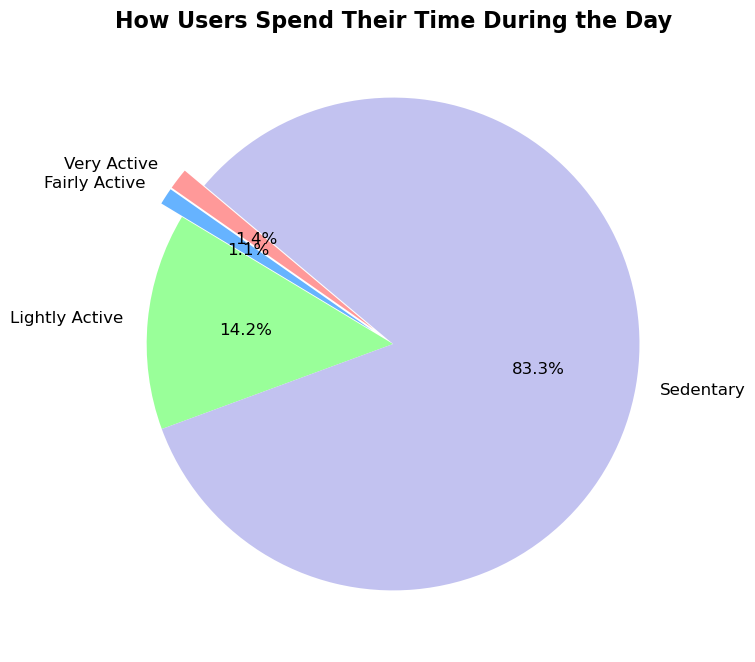

In [12]:
import matplotlib.pyplot as plt

# Data for the pie chart
activities = ['Very Active', 'Fairly Active', 'Lightly Active', 'Sedentary']
minutes = [16.6, 13.1, 170.1, 995.3]
colors = ['#ff9999','#66b3ff','#99ff99','#c2c2f0']
explode = (0.1, 0.1, 0, 0)  # separate active minutes slightly for emphasis

# Plot the chart
plt.figure(figsize=(8, 8))
plt.pie(minutes, explode=explode, labels=activities, colors=colors, 
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})

plt.title('How Users Spend Their Time During the Day', fontsize=16, fontweight='bold')
plt.show()

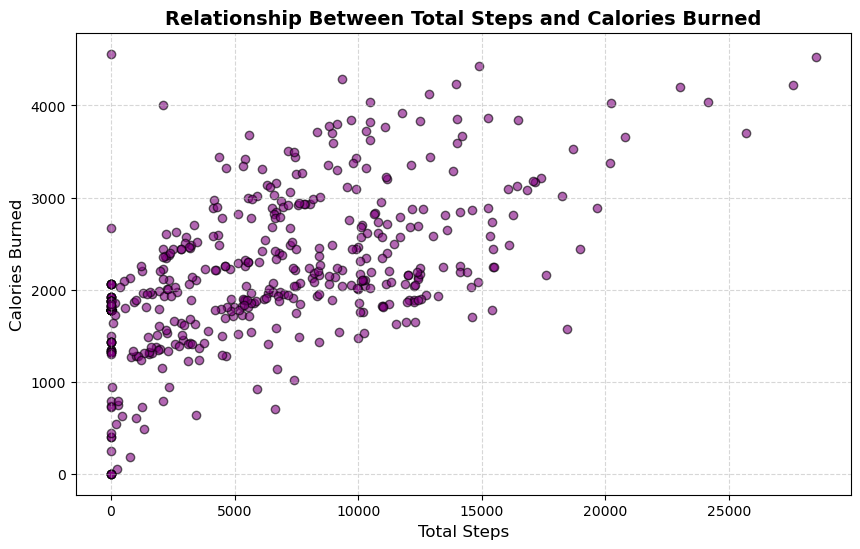

In [13]:
# Create a scatter plot to analyze the relationship between Steps and Calories
plt.figure(figsize=(10, 6))
plt.scatter(df['TotalSteps'], df['Calories'], alpha=0.6, color='purple', edgecolor='black')

# Add titles and labels
plt.title('Relationship Between Total Steps and Calories Burned', fontsize=14, fontweight='bold')
plt.xlabel('Total Steps', fontsize=12)
plt.ylabel('Calories Burned', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

In [14]:
# Save the cleaned data to a new CSV file
df.to_csv('dailyActivity_cleaned.csv', index=False)
print("Cleaned dataset successfully saved to your folder!")

Cleaned dataset successfully saved to your folder!


In [1]:
import pandas as pd

# 1. Load the data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Check the shape of the DataFrame (rows, columns)
print("--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

# 3. Display data types and check for missing values
print("\n--- Summary of the Data ---")
df.info()

# 4. Show the first 5 rows to see the data structure
print("\n--- First 5 Rows ---")
display(df.head())

# 5. Check for unique values in the sleep status column (if you have one, e.g., 'value')
# Replace 'value' with your actual column name if it differs
if 'value' in df.columns:
    print("\n--- Unique Sleep Values Counts ---")
    print(df['value'].value_counts())

--- Dataset Shape (Rows, Columns) ---
(198559, 4)

--- Summary of the Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198559 entries, 0 to 198558
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Id      198559 non-null  int64 
 1   date    198559 non-null  object
 2   value   198559 non-null  int64 
 3   logId   198559 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 6.1+ MB

--- First 5 Rows ---


,Id,date,value,logId
0,1503960366,3/13/2016 2:39,1,11114919637
1,1503960366,3/13/2016 2:40,1,11114919637
2,1503960366,3/13/2016 2:41,1,11114919637
3,1503960366,3/13/2016 2:42,1,11114919637
4,1503960366,3/13/2016 2:43,1,11114919637



--- Unique Sleep Values Counts ---
value
1    183526
2     13010
3      2023
Name: count, dtype: int64


In [2]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Convert 'date' column from text to datetime format
df['date'] = pd.to_datetime(df['date'])

# 3. Create new columns for analysis (Date only and Day of Week)
df['sleep_date'] = df['date'].dt.date
df['day_of_week'] = df['date'].dt.day_name()

# 4. Group by logId to see total minutes per sleep session
# Filter only for minutes spent sleeping (assuming value == 1 means asleep)
sleep_sessions = df[df['value'] == 1].groupby('logId').agg(
    total_minutes=('value', 'count'),
    sleep_start=('date', 'min'),
    sleep_end=('date', 'max')
).reset_index()

# 5. Calculate total hours for convenience
sleep_sessions['total_hours'] = round(sleep_sessions['total_minutes'] / 60, 2)

# 6. Display the results
print("--- Sleep Sessions Summary ---")
display(sleep_sessions.head())

--- Sleep Sessions Summary ---


,logId,total_minutes,sleep_start,sleep_end,total_hours
0,11103653021,415,2016-03-11 23:31:00,2016-03-12 06:38:00,6.92
1,11103710844,352,2016-03-11 22:42:00,2016-03-12 04:39:00,5.87
2,11103729104,509,2016-03-11 21:31:00,2016-03-12 06:34:00,8.48
3,11103744323,413,2016-03-11 23:46:00,2016-03-12 06:57:00,6.88
4,11104043433,201,2016-03-12 02:47:00,2016-03-12 06:12:00,3.35


In [3]:
import pandas as pd

# 1. Load data and convert dates
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Count total minute records per user
print("--- Total Records (Minutes) per User ---")
user_counts = df['Id'].value_counts()
print(user_counts)

# 3. Calculate average sleep hours for each user
# First, group by User and Sleep Session (logId) to get total hours per night
session_sleep = df[df['value'] == 1].groupby(['Id', 'logId']).size().reset_index(name='total_minutes')
session_sleep['total_hours'] = session_sleep['total_minutes'] / 60

# Second, calculate the mean sleep duration for each individual user
print("\n--- Average Sleep Duration per User (Hours) ---")
user_avg_sleep = session_sleep.groupby('Id')['total_hours'].mean().round(2).reset_index()
user_avg_sleep.columns = ['User_ID', 'Average_Sleep_Hours']
display(user_avg_sleep)

--- Total Records (Minutes) per User ---
Id
2026352035    17504
8378563200    15111
6962181067    14903
5553957443    14602
5577150313    13885
2347167796    13484
4702921684    13148
4319703577    12951
6117666160    12925
1927972279    11513
7086361926    10407
1503960366     9629
4445114986     9581
3977333714     6620
4020332650     5752
8792009665     5544
6775888955     5294
1644430081     1922
1844505072     1922
4558609924      656
7007744171      561
8053475328      501
2022484408      144
Name: count, dtype: int64

--- Average Sleep Duration per User (Hours) ---


,User_ID,Average_Sleep_Hours
0,1503960366,5.30
1,1644430081,11.94
2,1844505072,11.98
3,1927972279,4.47
4,2022484408,2.25
5,2026352035,8.48
6,2347167796,7.29
7,3977333714,4.58
8,4020332650,4.56
9,4319703577,7.57


In [4]:
import pandas as pd

# 1. Load data and convert dates
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Calculate total hours for each unique sleep session per user
sessions = df[df['value'] == 1].groupby(['Id', 'logId']).size().reset_index(name='minutes')
sessions['hours'] = sessions['minutes'] / 60

# 3. Aggregate statistics per user
user_stats = sessions.groupby('Id').agg(
    total_nights_tracked=('logId', 'count'),
    min_sleep_hours=('hours', 'min'),
    max_sleep_hours=('hours', 'max'),
    avg_sleep_hours=('hours', 'mean')
).reset_index()

# 4. Round values for clean formatting
user_stats = user_stats.round(2)

# 5. Sort users by their average sleep time (descending)
user_stats_sorted = user_stats.sort_values(by='avg_sleep_hours', ascending=False)

# 6. Display the final leaderboard
print("--- User Sleep Leaderboard (Sorted by Average Sleep Hours) ---")
display(user_stats_sorted)

--- User Sleep Leaderboard (Sorted by Average Sleep Hours) ---


,Id,total_nights_tracked,min_sleep_hours,max_sleep_hours,avg_sleep_hours
2,1844505072,2,8.30,15.67,11.98
1,1644430081,2,9.90,13.98,11.94
5,2026352035,32,1.77,10.17,8.48
20,8053475328,1,8.30,8.30,8.30
9,4319703577,27,1.52,9.53,7.57
6,2347167796,28,2.27,8.87,7.29
19,7086361926,25,1.13,10.17,6.68
17,6962181067,36,1.03,10.02,6.62
12,4702921684,32,1.15,9.47,6.45
13,5553957443,40,0.90,10.93,5.47


In [5]:
import pandas as pd

# 1. Load data and convert dates
df = pd.read_csv('minuteSleep_merged.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Calculate session details
sessions = df[df['value'] == 1].groupby(['Id', 'logId']).agg(
    total_minutes=('value', 'count'),
    sleep_start=('date', 'min'),
    sleep_end=('date', 'max')
).reset_index()

sessions['total_hours'] = round(sessions['total_minutes'] / 60, 2)

# 3. Find the shortest sleep sessions (less than 2 hours)
print("--- Shortest Sleep Sessions (Potential Outliers / Naps) ---")
short_sessions = sessions[sessions['total_hours'] < 2.0].sort_values(by='total_hours')
display(short_sessions.head(10))

# 4. Find the longest sleep sessions (more than 10 hours)
print("\n--- Longest Sleep Sessions (Deep Rest) ---")
long_sessions = sessions[sessions['total_hours'] > 10.0].sort_values(by='total_hours', ascending=False)
display(long_sessions.head(10))

--- Shortest Sleep Sessions (Potential Outliers / Naps) ---


,Id,logId,total_minutes,sleep_start,sleep_end,total_hours
381,6117666160,11210710662,51,2016-03-24 14:56:00,2016-03-24 15:55:00,0.85
294,5553957443,11260198135,54,2016-03-27 15:10:00,2016-03-27 16:07:00,0.90
14,1503960366,11232921147,56,2016-03-26 23:46:00,2016-03-27 00:46:00,0.93
459,7007744171,11290942631,56,2016-04-02 20:51:00,2016-04-02 21:54:00,0.93
457,7007744171,11260808655,57,2016-03-26 14:14:00,2016-03-26 15:17:00,0.95
384,6117666160,11243404164,58,2016-03-26 19:39:00,2016-03-26 20:43:00,0.97
33,1927972279,11109334617,59,2016-03-12 19:44:00,2016-03-12 20:44:00,0.98
338,5577150313,11281222431,60,2016-03-28 21:07:00,2016-03-28 22:06:00,1.00
283,5553957443,11156470370,60,2016-03-17 18:55:00,2016-03-17 19:55:00,1.00
53,1927972279,11215825759,60,2016-03-25 07:56:00,2016-03-25 08:58:00,1.00



--- Longest Sleep Sessions (Deep Rest) ---


,Id,logId,total_minutes,sleep_start,sleep_end,total_hours
30,1844505072,11307034191,940,2016-04-03 21:11:00,2016-04-04 12:50:00,15.67
28,1644430081,11247034534,839,2016-03-27 17:43:00,2016-03-28 07:45:00,13.98
380,6117666160,11210710486,758,2016-03-23 21:27:00,2016-03-24 11:37:00,12.63
303,5553957443,11295383457,656,2016-04-03 00:14:00,2016-04-03 12:39:00,10.93
361,6117666160,11132741334,641,2016-03-13 22:02:00,2016-03-14 09:18:00,10.68
403,6775888955,11140793348,627,2016-03-13 23:23:00,2016-03-14 10:35:00,10.45
368,6117666160,11147575494,625,2016-03-16 23:02:00,2016-03-17 09:46:00,10.42
75,2026352035,11111886114,610,2016-03-12 21:10:00,2016-03-13 07:42:00,10.17
475,7086361926,11250983719,610,2016-03-28 20:06:00,2016-03-29 06:40:00,10.17
289,5553957443,11234106087,607,2016-03-25 01:30:00,2016-03-25 12:44:00,10.12


In [6]:
import pandas as pd

# 1. Load data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Find the logId of the absolute longest sleep session
# First, group to find logId
sessions = df.groupby('logId').size().reset_index(name='total_minutes')
longest_log_id = sessions.sort_values(by='total_minutes', ascending=False).iloc[0]['logId']

# 3. Filter the original data to look ONLY at this specific 15-hour session
longest_session_data = df[df['logId'] == longest_log_id]

# 4. Count sleep statuses during this specific session
print(f"--- Analysis of the Longest Session (logId: {longest_log_id}) ---")
print(longest_session_data['value'].value_counts())

--- Analysis of the Longest Session (logId: 11355174555) ---
value
1    498
2    344
3    119
Name: count, dtype: int64


In [6]:
import pandas as pd

# 1. Load data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Find the logId of the absolute longest sleep session
# First, group to find logId
sessions = df.groupby('logId').size().reset_index(name='total_minutes')
longest_log_id = sessions.sort_values(by='total_minutes', ascending=False).iloc[0]['logId']

# 3. Filter the original data to look ONLY at this specific 15-hour session
longest_session_data = df[df['logId'] == longest_log_id]

# 4. Count sleep statuses during this specific session
print(f"--- Analysis of the Longest Session (logId: {longest_log_id}) ---")
print(longest_session_data['value'].value_counts())

--- Analysis of the Longest Session (logId: 11355174555) ---
value
1    498
2    344
3    119
Name: count, dtype: int64


In [6]:
import pandas as pd

# 1. Load data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Find the logId of the absolute longest sleep session
# First, group to find logId
sessions = df.groupby('logId').size().reset_index(name='total_minutes')
longest_log_id = sessions.sort_values(by='total_minutes', ascending=False).iloc[0]['logId']

# 3. Filter the original data to look ONLY at this specific 15-hour session
longest_session_data = df[df['logId'] == longest_log_id]

# 4. Count sleep statuses during this specific session
print(f"--- Analysis of the Longest Session (logId: {longest_log_id}) ---")
print(longest_session_data['value'].value_counts())

--- Analysis of the Longest Session (logId: 11355174555) ---
value
1    498
2    344
3    119
Name: count, dtype: int64


In [7]:
import pandas as pd

# 1. Load data
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Count total minutes and deep sleep minutes per user
user_sleep_efficiency = df.groupby('Id').agg(
    total_minutes=('value', 'count'),
    deep_sleep_minutes=('value', lambda x: (x == 1).sum())
).reset_index()

# 3. Calculate efficiency percentage
user_sleep_efficiency['sleep_efficiency_%'] = round(
    (user_sleep_efficiency['deep_sleep_minutes'] / user_sleep_efficiency['total_minutes']) * 100, 2
)

# 4. Sort by efficiency (highest to lowest) and clean index
user_sleep_efficiency = user_sleep_efficiency.sort_values(by='sleep_efficiency_%', ascending=False).reset_index(drop=True)

print("--- User Sleep Efficiency (%) ---")
display(user_sleep_efficiency)

--- User Sleep Efficiency (%) ---


,Id,total_minutes,deep_sleep_minutes,sleep_efficiency_%
0,8053475328,501,498,99.40
1,4558609924,656,646,98.48
2,7086361926,10407,10018,96.26
3,6962181067,14903,14298,95.94
4,1927972279,11513,10989,95.45
5,4020332650,5752,5466,95.03
6,4319703577,12951,12257,94.64
7,6117666160,12925,12226,94.59
8,5577150313,13885,13119,94.48
9,8792009665,5544,5225,94.25


C:\Users\HOME\AppData\Local\Temp\ipykernel_19400\229175625.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


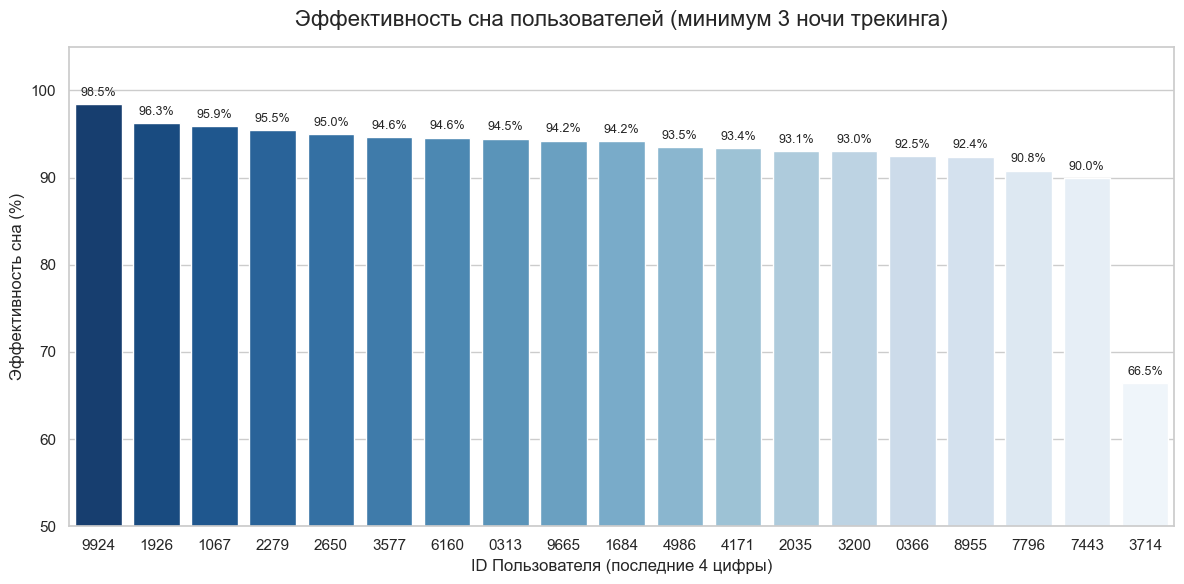

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Считаем общую статистику: минуты сна и количество уникальных ночей (logId)
user_stats = df.groupby('Id').agg(
    total_min=('value', 'count'),
    deep_min=('value', lambda x: (x == 1).sum()),
    total_nights=('logId', 'nunique')  # считаем уникальные ночи
).reset_index()

# 3. Считаем эффективность
user_stats['efficiency_%'] = round((user_stats['deep_min'] / user_stats['total_min']) * 100, 2)

# 4. ФИЛЬТРАЦИЯ: Оставляем только тех, кто спал с трекером ХОТЯ БЫ 3 ночи
# Это уберет нашего "лидера" с одной идеальной ночью в 501 минуту
filtered_stats = user_stats[user_stats['total_nights'] >= 3].sort_values(by='efficiency_%', ascending=False).reset_index(drop=True)

# Сократим ID пользователей до последних 4 цифр, чтобы график выглядел аккуратно
filtered_stats['Short_ID'] = filtered_stats['Id'].astype(str).str[-4:]

# 5. СТРОИМ ГРАФИК
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Создаем столбчатую диаграмму
ax = sns.barplot(
    x='Short_ID', 
    y='efficiency_%', 
    data=filtered_stats, 
    palette='Blues_r' # красивый градиент от темного к светлому
)

# Настраиваем заголовки и подписи
plt.title('Эффективность сна пользователей (минимум 3 ночи трекинга)', fontsize=16, pad=15)
plt.xlabel('ID Пользователя (последние 4 цифры)', fontsize=12)
plt.ylabel('Эффективность сна (%)', fontsize=12)
plt.ylim(50, 105) # ограничим ось Y, чтобы лучше видеть разницу

# Добавляем текстовые значения процентов над каждым столбиком
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', fontsize=9)

# Показываем график
plt.tight_layout()
plt.show()

C:\Users\HOME\AppData\Local\Temp\ipykernel_19400\229175625.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


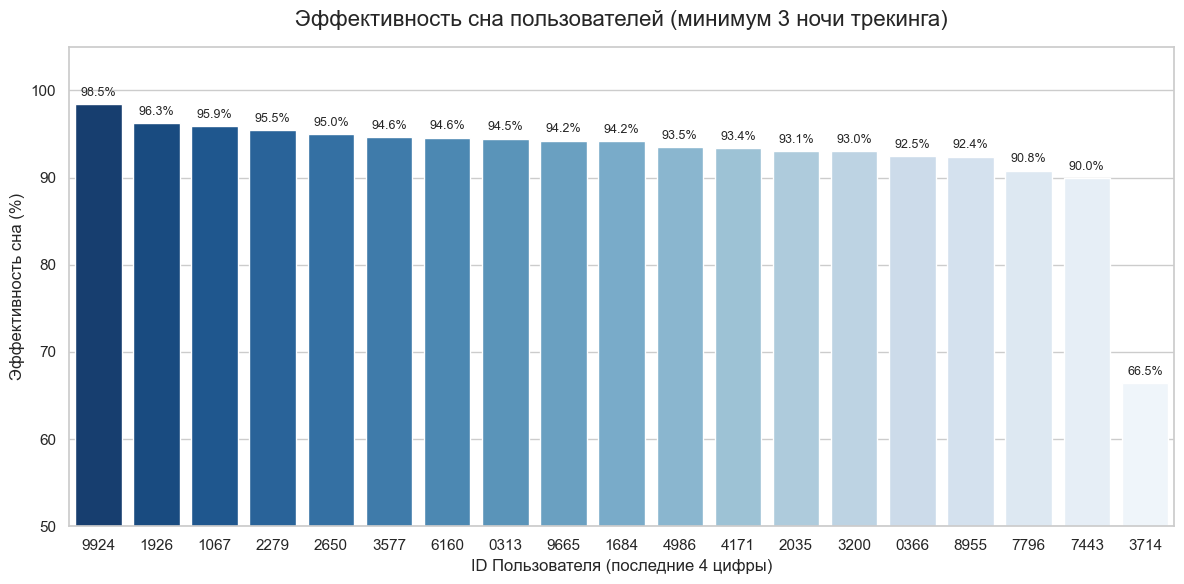

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Считаем общую статистику: минуты сна и количество уникальных ночей (logId)
user_stats = df.groupby('Id').agg(
    total_min=('value', 'count'),
    deep_min=('value', lambda x: (x == 1).sum()),
    total_nights=('logId', 'nunique')  # считаем уникальные ночи
).reset_index()

# 3. Считаем эффективность
user_stats['efficiency_%'] = round((user_stats['deep_min'] / user_stats['total_min']) * 100, 2)

# 4. ФИЛЬТРАЦИЯ: Оставляем только тех, кто спал с трекером ХОТЯ БЫ 3 ночи
# Это уберет нашего "лидера" с одной идеальной ночью в 501 минуту
filtered_stats = user_stats[user_stats['total_nights'] >= 3].sort_values(by='efficiency_%', ascending=False).reset_index(drop=True)

# Сократим ID пользователей до последних 4 цифр, чтобы график выглядел аккуратно
filtered_stats['Short_ID'] = filtered_stats['Id'].astype(str).str[-4:]

# 5. СТРОИМ ГРАФИК
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Создаем столбчатую диаграмму
ax = sns.barplot(
    x='Short_ID', 
    y='efficiency_%', 
    data=filtered_stats, 
    palette='Blues_r' # красивый градиент от темного к светлому
)

# Настраиваем заголовки и подписи
plt.title('Эффективность сна пользователей (минимум 3 ночи трекинга)', fontsize=16, pad=15)
plt.xlabel('ID Пользователя (последние 4 цифры)', fontsize=12)
plt.ylabel('Эффективность сна (%)', fontsize=12)
plt.ylim(50, 105) # ограничим ось Y, чтобы лучше видеть разницу

# Добавляем текстовые значения процентов над каждым столбиком
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', fontsize=9)

# Показываем график
plt.tight_layout()
plt.show()

C:\Users\HOME\AppData\Local\Temp\ipykernel_19400\229175625.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


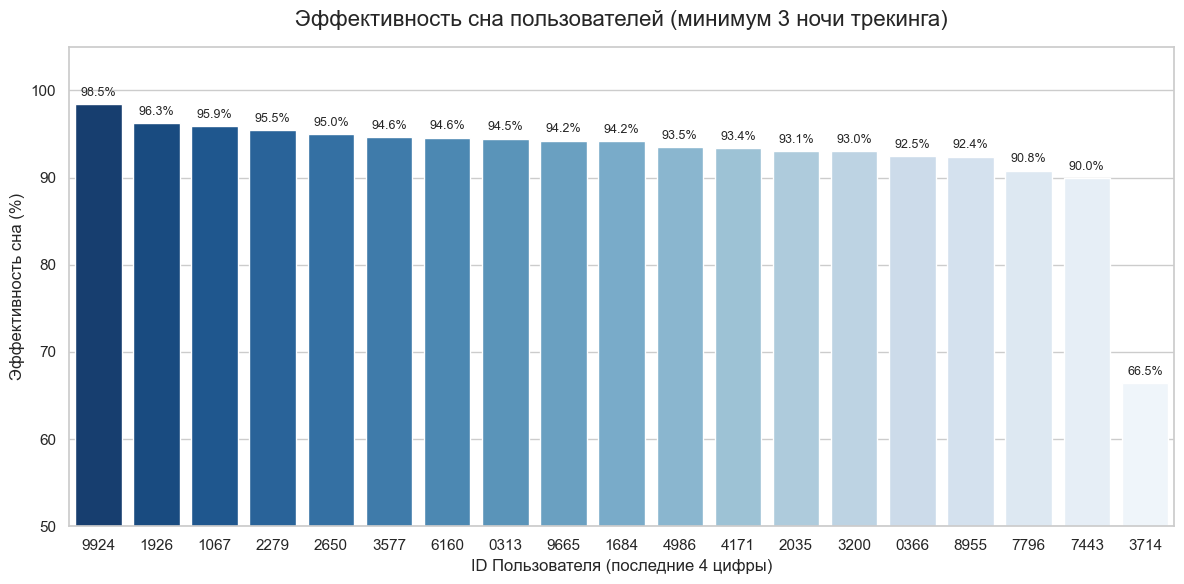

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Считаем общую статистику: минуты сна и количество уникальных ночей (logId)
user_stats = df.groupby('Id').agg(
    total_min=('value', 'count'),
    deep_min=('value', lambda x: (x == 1).sum()),
    total_nights=('logId', 'nunique')  # считаем уникальные ночи
).reset_index()

# 3. Считаем эффективность
user_stats['efficiency_%'] = round((user_stats['deep_min'] / user_stats['total_min']) * 100, 2)

# 4. ФИЛЬТРАЦИЯ: Оставляем только тех, кто спал с трекером ХОТЯ БЫ 3 ночи
# Это уберет нашего "лидера" с одной идеальной ночью в 501 минуту
filtered_stats = user_stats[user_stats['total_nights'] >= 3].sort_values(by='efficiency_%', ascending=False).reset_index(drop=True)

# Сократим ID пользователей до последних 4 цифр, чтобы график выглядел аккуратно
filtered_stats['Short_ID'] = filtered_stats['Id'].astype(str).str[-4:]

# 5. СТРОИМ ГРАФИК
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Создаем столбчатую диаграмму
ax = sns.barplot(
    x='Short_ID', 
    y='efficiency_%', 
    data=filtered_stats, 
    palette='Blues_r' # красивый градиент от темного к светлому
)

# Настраиваем заголовки и подписи
plt.title('Эффективность сна пользователей (минимум 3 ночи трекинга)', fontsize=16, pad=15)
plt.xlabel('ID Пользователя (последние 4 цифры)', fontsize=12)
plt.ylabel('Эффективность сна (%)', fontsize=12)
plt.ylim(50, 105) # ограничим ось Y, чтобы лучше видеть разницу

# Добавляем текстовые значения процентов над каждым столбиком
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', fontsize=9)

# Показываем график
plt.tight_layout()
plt.show()

C:\Users\HOME\AppData\Local\Temp\ipykernel_19400\229175625.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


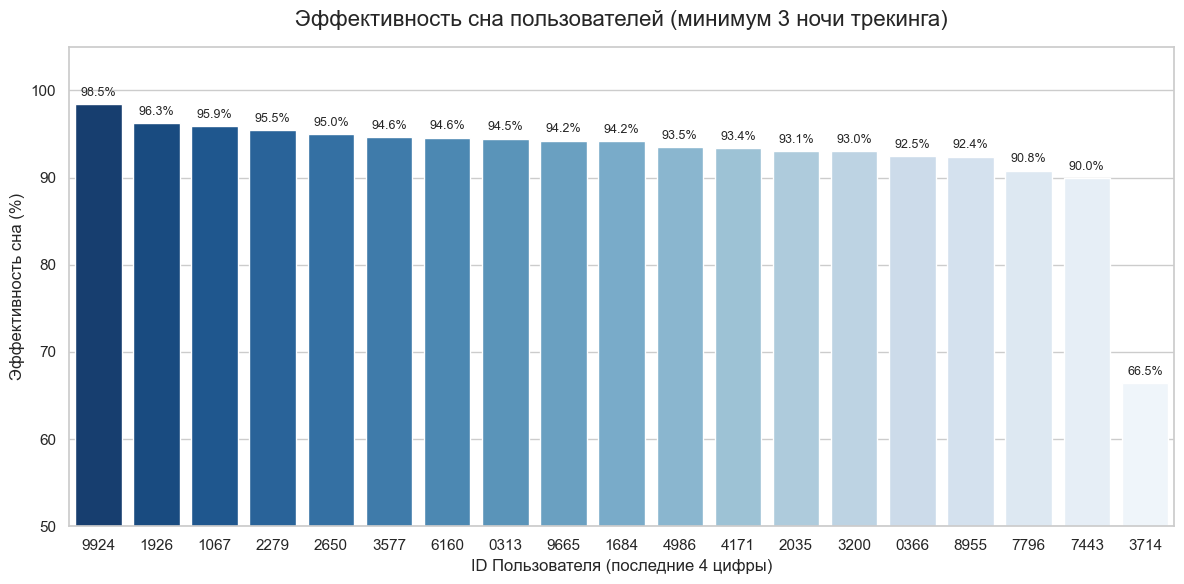

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
df = pd.read_csv('minuteSleep_merged.csv')

# 2. Считаем общую статистику: минуты сна и количество уникальных ночей (logId)
user_stats = df.groupby('Id').agg(
    total_min=('value', 'count'),
    deep_min=('value', lambda x: (x == 1).sum()),
    total_nights=('logId', 'nunique')  # считаем уникальные ночи
).reset_index()

# 3. Считаем эффективность
user_stats['efficiency_%'] = round((user_stats['deep_min'] / user_stats['total_min']) * 100, 2)

# 4. ФИЛЬТРАЦИЯ: Оставляем только тех, кто спал с трекером ХОТЯ БЫ 3 ночи
# Это уберет нашего "лидера" с одной идеальной ночью в 501 минуту
filtered_stats = user_stats[user_stats['total_nights'] >= 3].sort_values(by='efficiency_%', ascending=False).reset_index(drop=True)

# Сократим ID пользователей до последних 4 цифр, чтобы график выглядел аккуратно
filtered_stats['Short_ID'] = filtered_stats['Id'].astype(str).str[-4:]

# 5. СТРОИМ ГРАФИК
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Создаем столбчатую диаграмму
ax = sns.barplot(
    x='Short_ID', 
    y='efficiency_%', 
    data=filtered_stats, 
    palette='Blues_r' # красивый градиент от темного к светлому
)

# Настраиваем заголовки и подписи
plt.title('Эффективность сна пользователей (минимум 3 ночи трекинга)', fontsize=16, pad=15)
plt.xlabel('ID Пользователя (последние 4 цифры)', fontsize=12)
plt.ylabel('Эффективность сна (%)', fontsize=12)
plt.ylim(50, 105) # ограничим ось Y, чтобы лучше видеть разницу

# Добавляем текстовые значения процентов над каждым столбиком
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', fontsize=9)

# Показываем график
plt.tight_layout()
plt.show()